# Task 2.2 - Reproduction of One Contribution from the Paper

## Reproduction Target

**Contribution reproduced:** Prefix-based early prediction trend relative to full-length 1NN behavior.

**Metric used:** Test accuracy (same metric family used in the paper's 1NN comparisons).

**Protocol note:** FordA remains length 500; prefixes are evaluated from 10% to 100%.


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

CONFIG = {
    'seed': 42,
    'prefix_ratios': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'n_neighbors': 1,
    'metric': 'euclidean',
}

np.random.seed(CONFIG['seed'])

DATA_DIR = Path('data')
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

train_df = pd.read_csv(DATA_DIR / 'FordA_TRAIN.tsv', sep='	', header=None)
test_df = pd.read_csv(DATA_DIR / 'FordA_TEST.tsv', sep='	', header=None)

X_train = train_df.iloc[:, 1:].to_numpy(dtype=float)
X_test = test_df.iloc[:, 1:].to_numpy(dtype=float)
y_train = (train_df.iloc[:, 0].to_numpy(dtype=int) == 1).astype(int)
y_test = (test_df.iloc[:, 0].to_numpy(dtype=int) == 1).astype(int)

print('Data loaded:', X_train.shape, X_test.shape)

Data loaded: (3601, 500) (1320, 500)


**Cell 1 - What this code does:**
Initializes configuration, loads FordA, prepares `X_train/X_test` and binary labels, and confirms shapes.

**Paper connection:**
Creates the fixed-length time-series setting needed before analyzing prefix spaces.


In [14]:
def evaluate_prefix(prefix_ratio, metric='euclidean'):
    prefix_len = max(1, int(X_train.shape[1] * prefix_ratio))
    clf = KNeighborsClassifier(
        n_neighbors=CONFIG['n_neighbors'],
        metric=metric,
        n_jobs=-1,
    )
    clf.fit(X_train[:, :prefix_len], y_train)
    preds = clf.predict(X_test[:, :prefix_len])
    acc = accuracy_score(y_test, preds)
    return prefix_len, acc

full_len, baseline_acc = evaluate_prefix(1.0, metric=CONFIG['metric'])
print(f'Full-length baseline (1NN, {CONFIG["metric"]}) accuracy: {baseline_acc:.4f}')
print(f'Full length used: {full_len}')

Full-length baseline (1NN, euclidean) accuracy: 0.6652
Full length used: 500


**Cell 2 - What this code does:**
Defines `evaluate_prefix(...)`, which trains 1NN on the first `l` timestamps and evaluates accuracy on the same prefix length. It also computes the full-length baseline at 100% prefix.

**Paper connection:**
Implements the core early-classification idea: prediction quality as a function of observed prefix length.


In [15]:
records = []
for ratio in CONFIG['prefix_ratios']:
    length, acc = evaluate_prefix(ratio, metric=CONFIG['metric'])
    records.append({'prefix_ratio': ratio, 'prefix_length': length, 'accuracy': acc})

results_df = pd.DataFrame(records)
results_df['prefix_percent'] = (results_df['prefix_ratio'] * 100).astype(int)
results_df = results_df[['prefix_ratio', 'prefix_percent', 'prefix_length', 'accuracy']]
results_df

,prefix_ratio,prefix_percent,prefix_length,accuracy
0,0.1,10,50,0.626515
1,0.2,20,100,0.656818
2,0.3,30,150,0.653030
3,0.4,40,200,0.658333
4,0.5,50,250,0.629545
5,0.6,60,300,0.656061
6,0.7,70,350,0.657576
7,0.8,80,400,0.665152
8,0.9,90,450,0.679545
9,1.0,100,500,0.665152


**Cell 3 - What this code does:**
Runs the prefix sweep over ratios 10%-100%, and stores accuracy with exact prefix lengths.

**Paper connection:**
Produces the empirical curve needed to assess how quickly prefix-based decisions approach full-length behavior.


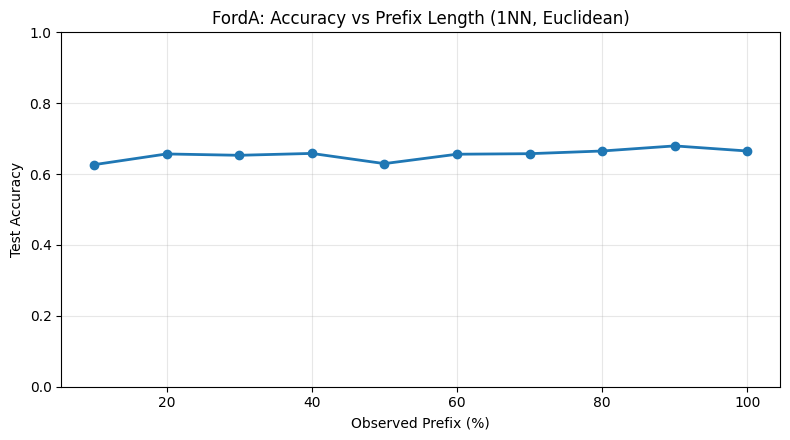

Saved: results/task_2_2_prefix_accuracy.csv
Saved: results/task_2_2_accuracy_vs_prefix.png


In [16]:
results_df.to_csv(RESULTS_DIR / 'task_2_2_prefix_accuracy.csv', index=False)

plt.figure(figsize=(8, 4.5))
plt.plot(results_df['prefix_percent'], results_df['accuracy'], marker='o', linewidth=2)
plt.xlabel('Observed Prefix (%)')
plt.ylabel('Test Accuracy')
plt.title('FordA: Accuracy vs Prefix Length (1NN, Euclidean)')
plt.grid(alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'task_2_2_accuracy_vs_prefix.png', dpi=200)
plt.show()

print('Saved: results/task_2_2_prefix_accuracy.csv')
print('Saved: results/task_2_2_accuracy_vs_prefix.png')

## Task 2.2 Result Snapshot

This cell saves the main artifacts for later tasks:
- `results/task_2_2_prefix_accuracy.csv`
- `results/task_2_2_accuracy_vs_prefix.png`

The curve captures the key reproduction evidence: whether useful classification performance is achieved before full sequence observation.


## Interpretation

If accuracy at shorter prefixes gets close to the 100% prefix baseline, that supports the paper's practical claim that useful decisions can be made early. This notebook establishes that trend; Task 2.3 formalizes it with a near-baseline stability rule.
